# Python for (open) Neuroscience  
### Lecture 2.4 — *Data organization and analysis*
#### Module 02 - Scientific Stack
Sara Assecondi

Department of Psychology and Cognitive Sciences

>**Goal of this lecture:** learn how to organize real datasets into clean analysis-ready tables and perform more powerful operations such as grouping, aggregating, merging, reshaping, handling missing data, and working with indexes.

[Pandas documentation](https://pandas.pydata.org/docs/)


## Learning goals

By the end of this notebook you should be able to:

- build dataframes from dictionaries, arrays, and files
- add rows and columns
- handle missing values
- organize data in a *flat* / tidy way
- aggregate data with `.groupby()`
- combine datasets with `concat` and `merge`
- work with aligned indexes
- use multi-indexing and rolling windows


In [2]:
import numpy as np
import pandas as pd
np.random.seed(0)


## Creating dataframes

Although many analyses start from files, it is important to know the main building patterns.


In [3]:
pd.DataFrame({
    "int_col": [1, 2, 3],
    "float_col": [4.0, 5.0, 0.6],
    "str_col": ["a", "b", "c"],
})


,int_col,float_col,str_col
0,1,4.0,a
1,2,5.0,b
2,3,0.6,c


In [4]:
pd.DataFrame([
    {"int_col": 1, "float_col": 4.0, "str_col": "a"},
    {"int_col": 2, "float_col": 5.0, "str_col": "b"},
    {"int_col": 3, "float_col": 0.6, "str_col": "c"},
])


,int_col,float_col,str_col
0,1,4.0,a
1,2,5.0,b
2,3,0.6,c


In [5]:
twod_array = np.random.rand(4, 3)
pd.DataFrame(twod_array, columns=["a", "b", "c"])


,a,b,c
0,0.548814,0.715189,0.602763
1,0.544883,0.423655,0.645894
2,0.437587,0.891773,0.963663
3,0.383442,0.791725,0.528895


### Reading from files


In [ ]:
#URL = path to a file on your computer filename.csv
df = pd.read_csv(URL)
df.head()


### Adding columns and rows


In [9]:
df_small = pd.DataFrame(
    np.random.rand(3, 3),
    columns=["a", "b", "c"],
    index=["row1", "row2", "row3"],
)

df_small

,a,b,c
row1,0.681820,0.359508,0.437032
row2,0.697631,0.060225,0.666767
row3,0.670638,0.210383,0.128926


In [10]:
df_small["group"] = ["A", "A", "B"]
df_small["constant"] = 42
df_small

,a,b,c,group,constant
row1,0.681820,0.359508,0.437032,A,42
row2,0.697631,0.060225,0.666767,A,42
row3,0.670638,0.210383,0.128926,B,42


In [ ]:
### Concatenating

In [12]:
df1 = pd.DataFrame(dict(col1=[99, 95, 92], col2=[95, 90, 99]))
df1


,col1,col2
0,99,95
1,95,90
2,92,99


In [14]:
df2 = pd.DataFrame(dict(col1=[100], col2=[101]))
df2


,col1,col2
0,100,101


In [15]:
pd.concat([df1, df2]).reset_index(drop=True)

,col1,col2
0,99,95
1,95,90
2,92,99
3,100,101


## Handling missing data
### Missing values

Missing values are represented as `NaN`.  
They commonly appear after concatenation, joins, or incomplete measurements.


In [18]:
df1 = pd.DataFrame(dict(col1=[99, 95, 92], col2=[95, 90, 99]))
df2 = pd.DataFrame(dict(col1=[100], different_col=[101]))
missing_df = pd.concat([df1, df2], ignore_index=True)
missing_df


,col1,col2,different_col
0,99,95.0,NaN
1,95,90.0,NaN
2,92,99.0,NaN
3,100,NaN,101.0


In [19]:
missing_df.isna()
# returns an array of boolean indicating whether each corresponding element is missing

,col1,col2,different_col
0,False,False,True
1,False,False,True
2,False,False,True
3,False,True,False


In [20]:
numeric_missing = pd.DataFrame({
    "column_a": [0, 3, 1, 2, np.nan, 4, 10],
    "column_b": [7, 6, np.nan, 4, 5, 7, 8],
})
numeric_missing


,column_a,column_b
0,0.0,7.0
1,3.0,6.0
2,1.0,NaN
3,2.0,4.0
4,NaN,5.0
5,4.0,7.0
6,10.0,8.0


### Interpolate values

In [21]:
numeric_missing.interpolate()
# for dataframe a linear interpolation is performed

,column_a,column_b
0,0.0,7.0
1,3.0,6.0
2,1.0,5.0
3,2.0,4.0
4,3.0,5.0
5,4.0,7.0
6,10.0,8.0


## Why dataframes

A common mistake is to store experimental data in nested Python objects.
That is valid Python, but not a good format for analysis.


In [22]:
n_subjects = 4
n_repetitions = 3

all_subjects_data = {}
for i in range(n_subjects):
    all_subjects_data[f"subj_{i}"] = [
        {"accuracy": np.random.rand(), "speed": np.random.rand()}
        for _ in range(n_repetitions)
    ]

all_subjects_data


{'subj_0': [{'accuracy': 0.31542835092418386, 'speed': 0.3637107709426226},
  {'accuracy': 0.5701967704178796, 'speed': 0.43860151346232035},
  {'accuracy': 0.9883738380592262, 'speed': 0.10204481074802807}],
 'subj_1': [{'accuracy': 0.2088767560948347, 'speed': 0.16130951788499626},
  {'accuracy': 0.6531083254653984, 'speed': 0.2532916025397821},
  {'accuracy': 0.4663107728563063, 'speed': 0.24442559200160274}],
 'subj_2': [{'accuracy': 0.15896958364551972, 'speed': 0.11037514116430513},
  {'accuracy': 0.6563295894652734, 'speed': 0.1381829513486138},
  {'accuracy': 0.1965823616800535, 'speed': 0.3687251706609641}],
 'subj_3': [{'accuracy': 0.8209932298479351, 'speed': 0.09710127579306127},
  {'accuracy': 0.8379449074988039, 'speed': 0.09609840789396307},
  {'accuracy': 0.9764594650133958, 'speed': 0.4686512016477016}]}

In [23]:
means = []
for subject_results in all_subjects_data.values():
    for result in subject_results:
        means.append(result["speed"])
np.mean(means)


np.float64(0.2368764963406634)

Nested data are hard to query and summarize.

A better idea is to store **one row per observation** and **one column per variable**.


In [24]:
flat_list_of_dicts = []
for sub in all_subjects_data.keys():
    for repetition in range(n_repetitions):
        trial_dict = all_subjects_data[sub][repetition].copy()
        trial_dict.update({"subject": sub, "repetition": repetition})
        flat_list_of_dicts.append(trial_dict)

trials_df = pd.DataFrame(flat_list_of_dicts)
trials_df


,accuracy,speed,subject,repetition
0,0.315428,0.363711,subj_0,0
1,0.570197,0.438602,subj_0,1
2,0.988374,0.102045,subj_0,2
3,0.208877,0.161310,subj_1,0
4,0.653108,0.253292,subj_1,1
5,0.466311,0.244426,subj_1,2
6,0.158970,0.110375,subj_2,0
7,0.656330,0.138183,subj_2,1
8,0.196582,0.368725,subj_2,2
9,0.820993,0.097101,subj_3,0


In [25]:
trials_df["speed"].mean()


np.float64(0.2368764963406634)

## Operations with dataframes
### Split into different tables

For example, we may have:

- one dataframe for **trial-level** data
- one dataframe for **subject-level** metadata
- one key column that lets you link them


In [26]:
subjects_df = pd.DataFrame({
    "sex": np.random.choice(["F", "M"], size=n_subjects),
    "handedness": np.random.choice(["left", "right"], size=n_subjects),
    "age": np.random.randint(20, 40, size=n_subjects),
})
subjects_df.index = [f"subj_{i}" for i in range(n_subjects)]
subjects_df


,sex,handedness,age
subj_0,M,right,38
subj_1,F,right,31
subj_2,M,left,22
subj_3,M,left,22


In [28]:
# find subjects younger than 31
selected_subjects_df = subjects_df[subjects_df["age"] <= 30]

# take the corresponding indexes
sel_subjects_ids = selected_subjects_df.index

# find the trials of the selected subjects
selection = trials_df["subject"].isin(sel_subjects_ids)

# average only those trials
trials_df.loc[selection, "speed"].mean()


np.float64(0.21318902475143484)

### `groupby()`: aggregate within categories

- Sometimes we want the mean of a certain variable for each subject
- we use `group_by`


In [30]:
# average within subjects, over repetitions
trials_df.groupby("subject").mean(numeric_only=True)


,accuracy,speed,repetition
subject,,,
subj_0,0.624666,0.301452,1.0
subj_1,0.442765,0.219676,1.0
subj_2,0.337294,0.205761,1.0
subj_3,0.878466,0.220617,1.0


In [29]:
# average within repetitions, over 
# we drop `subject` because it is a string
trials_df.drop(columns=["subject"]).groupby("repetition").mean(numeric_only=True)


,accuracy,speed
repetition,,
0,0.376067,0.183124
1,0.679395,0.231544
2,0.656932,0.295962


### `merge`: combining dataframes by keys

Use `merge` when two tables describe different aspects of the same entities.

- `subjects_df` take trials_df and bring in columns from subjects_df
- `left_on="subject"` In trials_df, use the column "subject" as the matching key
- in `subjects_df`, do not use a column as the key, use the `index`
- `how="left"`, keep all rows from `trials_df`, even if some subjects are missing from `subjects_df`

In [31]:
trials_with_subject_info = trials_df.merge(
    subjects_df,
    left_on="subject",  # column or index level names to join on in the left DataFrame
    right_index=True,   # use the index from the right DataFrame as the join key
    how="left",         # use only keys from left frame
)
trials_with_subject_info.head()


,accuracy,speed,subject,repetition,sex,handedness,age
0,0.315428,0.363711,subj_0,0,M,right,38
1,0.570197,0.438602,subj_0,1,M,right,38
2,0.988374,0.102045,subj_0,2,M,right,38
3,0.208877,0.161310,subj_1,0,F,right,31
4,0.653108,0.253292,subj_1,1,F,right,31


### `pivot_table`: reshaping summaries 


In [36]:
trials_with_subject_info["trial_type"] = np.where(
    trials_with_subject_info["repetition"] % 2 == 0,
    "type_A", 
    "type_B",
)

trials_with_subject_info.head(5)

,accuracy,speed,subject,repetition,sex,handedness,age,trial_type
0,0.315428,0.363711,subj_0,0,M,right,38,type_A
1,0.570197,0.438602,subj_0,1,M,right,38,type_B
2,0.988374,0.102045,subj_0,2,M,right,38,type_A
3,0.208877,0.161310,subj_1,0,F,right,31,type_A
4,0.653108,0.253292,subj_1,1,F,right,31,type_B


In [39]:
pd.pivot_table(
    trials_with_subject_info,
    values="speed",
    index="subject",
    columns="trial_type",
    aggfunc="mean",
)


trial_type,type_A,type_B
subject,,
subj_0,0.232878,0.438602
subj_1,0.202868,0.253292
subj_2,0.239550,0.138183
subj_3,0.282876,0.096098


## Alignment and broadcasting in pandas

When we do arithmetic between dataframes or series, pandas aligns data by labels, not just by position.


In [45]:
df_a = pd.DataFrame(dict(col_a=[10, 20], col_b=[15, 25]))
df_b = pd.DataFrame(dict(col_b=[1, 2], col_a=[3, 4]))

print("df_a = ")
print(df_a)

print("df_ b= ")
print(df_b)

df_a = 
   col_a  col_b
0     10     15
1     20     25
df_ b= 
   col_b  col_a
0      1      3
1      2      4


In [46]:
df_a - df_b

,col_a,col_b
0,7,14
1,16,23


In [48]:
df_a = pd.DataFrame(dict(col_a=[10, 20], col_b=[15, 25]), index=["trial0", "trial1"])
df_b = pd.DataFrame(dict(col_b=[1, 2], col_a=[3, 4]), index=["trial1", "trial0"])

print("df_a = ")
print(df_a)

print("df_ b= ")
print(df_b)

df_a = 
        col_a  col_b
trial0     10     15
trial1     20     25
df_ b= 
        col_b  col_a
trial1      1      3
trial0      2      4


In [49]:
df_a - df_b

,col_a,col_b
trial0,6,13
trial1,17,24


In [50]:
df_a = pd.DataFrame(dict(col_a=[10, 20], col_b=[15, 25]), index=["trial0", "trial1"])
df_b = pd.DataFrame(dict(col_b=[1, 2], col_a=[3, 4], col_c=[0, 0]), index=["trial1", "trial2"])
print("df_a = ")
print(df_a)

print("df_ b= ")
print(df_b)

df_a = 
        col_a  col_b
trial0     10     15
trial1     20     25
df_ b= 
        col_b  col_a  col_c
trial1      1      3      0
trial2      2      4      0


In [51]:
df_a - df_b

,col_a,col_b,col_c
trial0,NaN,NaN,NaN
trial1,17.0,24.0,NaN
trial2,NaN,NaN,NaN


## Groupby and broadcasting

This pattern is very useful for normalization within subject, session, block, condition, etc.


In [54]:
normalized_trials_df = (
    trials_df.set_index("subject")
    - trials_df.groupby("subject").mean(numeric_only=True)
)
normalized_trials_df

,accuracy,speed,repetition
subject,,,
subj_0,-0.309238,0.062258,-1.0
subj_0,-0.054470,0.137149,0.0
subj_0,0.363708,-0.199408,1.0
subj_1,-0.233889,-0.058366,-1.0
subj_1,0.210343,0.033616,0.0
subj_1,0.023545,0.024750,1.0
subj_2,-0.178324,-0.095386,-1.0
subj_2,0.319036,-0.067578,0.0
subj_2,-0.140711,0.162964,1.0


In [55]:
normalized_trials_df.reset_index()

,subject,accuracy,speed,repetition
0,subj_0,-0.309238,0.062258,-1.0
1,subj_0,-0.054470,0.137149,0.0
2,subj_0,0.363708,-0.199408,1.0
3,subj_1,-0.233889,-0.058366,-1.0
4,subj_1,0.210343,0.033616,0.0
5,subj_1,0.023545,0.024750,1.0
6,subj_2,-0.178324,-0.095386,-1.0
7,subj_2,0.319036,-0.067578,0.0
8,subj_2,-0.140711,0.162964,1.0
9,subj_3,-0.057473,-0.123516,-1.0


## Hierarchical indexing

Grouping over multiple variables gives a hierarchical index.


In [56]:
n_trials = 4
trials_df2 = pd.DataFrame({
    "subject": [f"subj{i}" for i in range(n_subjects) for _ in range(n_trials)],
    "trial_type": [f"type{n // 2}" for i in range(n_subjects) for n in range(n_trials)],
    "accuracy": np.random.uniform(0, 1, n_trials * n_subjects),
    "rt": np.random.uniform(0, 100, n_trials * n_subjects),
})
trials_df2.head()


,subject,trial_type,accuracy,rt
0,subj0,type0,0.880476,55.282148
1,subj0,type0,0.918235,16.494046
2,subj0,type1,0.216822,36.980809
3,subj0,type1,0.565189,14.644176
4,subj1,type0,0.865103,56.961841


In [57]:
trial_subj_avg = trials_df2.groupby(["subject", "trial_type"]).mean(numeric_only=True)
trial_subj_avg


accuracy         rt
subject trial_type                     
subj0   type0       0.899356  35.888097
        type1       0.391006  25.812493
subj1   type0       0.687036  63.667784
        type1       0.918940  36.088225
subj2   type0       0.180416  57.610248
        type1       0.425849  76.747973
subj3   type0       0.744280  78.580500
        type1       0.331275  71.388433

In [58]:
trials_df2.set_index(["subject", "trial_type"]) - trial_subj_avg


accuracy         rt
subject trial_type                     
subj0   type0      -0.018880  19.394051
        type0       0.018880 -19.394051
        type1      -0.174183  11.168317
        type1       0.174183 -11.168317
subj1   type0       0.178067  -6.705944
        type0      -0.178067   6.705944
        type1      -0.002217  -7.240581
        type1       0.002217   7.240581
subj2   type0      -0.097303  18.000421
        type0       0.097303 -18.000421
        type1      -0.416493  12.855866
        type1       0.416493 -12.855866
subj3   type0      -0.097106  10.574943
        type0       0.097106 -10.574943
        type1      -0.066545 -26.468660
        type1       0.066545  26.468660

## Moving windows: `rolling`

Operations over moving windows are useful for time series, smoothing, running statistics, and local summaries.


<Axes: >

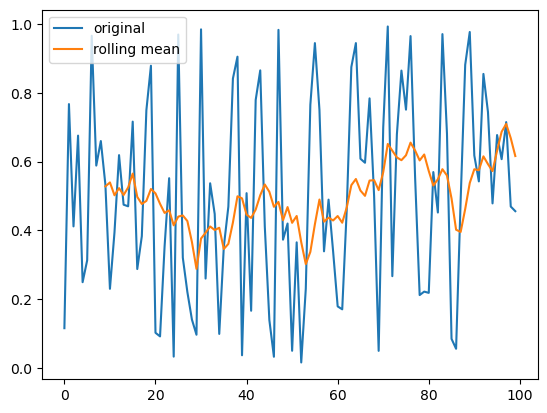

In [59]:
time_series = pd.Series(np.random.rand(100))
smoothed = time_series.rolling(10).mean()

ax = time_series.plot(legend=True, label="original")
smoothed.plot(ax=ax, legend=True, label="rolling mean")


<Axes: >

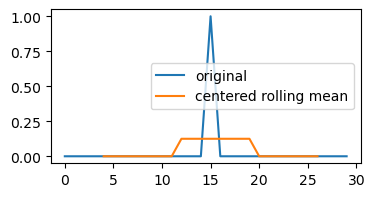

In [60]:
dirac_series = pd.Series(np.zeros(30))
dirac_series[15] = 1

ax = dirac_series.plot(figsize=(4, 2), legend=True, label="original")
dirac_series.rolling(8, center=True).mean().plot(ax=ax, legend=True, label="centered rolling mean")
# `center=True` set the window labels as the center of the window index